<a href="https://colab.research.google.com/github/FattahulAlim/MFattahul-PCVK_ganjil_2026/blob/main/Week5_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Identitas Diri
Nama: Muhammad Fattahul Alim

NIM: 244107020018

Kelas: TI - 3G

Absen : 15

NAMA : Muhammad Fattahul Alim
NIM : 244107020018 | N = 18
bins   : 32
clip   : 2.5
tile   : 4
L      : 2
WAKTU : 2026-09-26 20:22:48 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 504d0028c82eb5e5


Text(0.5, 1.0, '244107020018 - CLAHE clip 2.5')

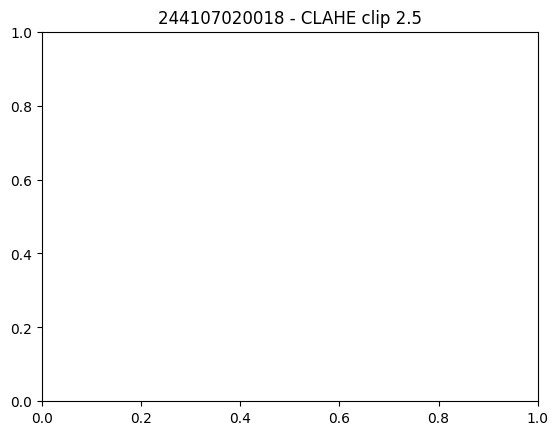

In [ ]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
import matplotlib.pyplot as plt

NAMA = 'Muhammad Fattahul Alim'
NIM = '244107020018' # ganti dengan NIM Anda
N = int(NIM[-3:])
PARAM = {
'bins' : 2 ** ((N % 4) + 3),
'clip' : round(1.0 + (N % 5) * 0.5, 1),
'tile' : (N % 4) + 2,
'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])
plt.title(NIM + ' - CLAHE clip ' + str(PARAM['clip']))

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

In [ ]:
CONTOH = '/content/drive/MyDrive/PCVK-MFattahul/week-5/'
BASE = '/content/drive/MyDrive/PCVK-MFattahul/week-5/'

# E-1 Percobaan Histogram

=== Perbandingan histogram: lena.jpg ===
Kanal red   | manual vs numpy: 0 | manual vs cv: 0 | numpy vs cv: 0
Kanal green | manual vs numpy: 0 | manual vs cv: 0 | numpy vs cv: 0
Kanal blue  | manual vs numpy: 0 | manual vs cv: 0 | numpy vs cv: 0


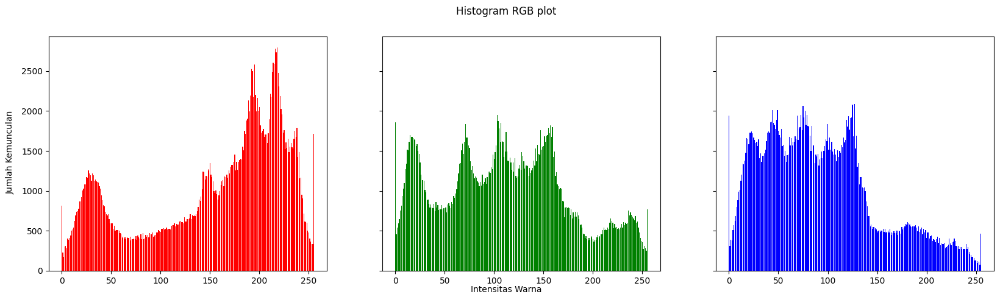

In [ ]:
# E-1 dan pertanyaan praktikum 1
img = cv.imread(CONTOH + 'lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

manual_red = [0] * 256
manual_green = [0] * 256
manual_blue = [0] * 256

for y in range(0, height):
  for x in range(0, width):
    manual_red[img[y, x, 0]] += 1
    manual_green[img[y, x, 1]] += 1
    manual_blue[img[y, x, 2]] += 1

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex= True, sharey= True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va = 'center', rotation = 'vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha = 'center')
axs[0].bar(names, manual_red, color = 'red')
axs[1].bar(names, manual_green, color = 'green')
axs[2].bar(names, manual_blue, color = 'blue')

# Histogram citra dengan numpy.histogram lena
np_red, _ = np.histogram(img[:, :, 0], bins=256, range=(0, 256))
np_green, _ = np.histogram(img[:, :, 1], bins=256, range=(0, 256))
np_blue, _ = np.histogram(img[:, :, 2], bins=256, range=(0, 256))

# Histogram citra dengan cv.calchist
cv_red = cv.calcHist([img], [0], None, [256], [0, 256]).flatten().astype(int)
cv_green = cv.calcHist([img], [1], None, [256], [0, 256]).flatten().astype(int)
cv_blue = cv.calcHist([img], [2], None, [256], [0, 256]).flatten().astype(int)

# Perbandingan selisih maksimum
print("=== Perbandingan histogram: lena.jpg ===")

diff_r_manual_np = np.max(np.abs(manual_red - np_red))
diff_r_manual_cv = np.max(np.abs(manual_red - cv_red))
diff_r_np_cv = np.max(np.abs(np_red - cv_red))
print(f"Kanal red   | manual vs numpy: {diff_r_manual_np} | manual vs cv: {diff_r_manual_cv} | numpy vs cv: {diff_r_np_cv}")

diff_g_manual_np = np.max(np.abs(manual_green - np_green))
diff_g_manual_cv = np.max(np.abs(manual_green - cv_green))
diff_g_np_cv = np.max(np.abs(np_green - cv_green))
print(f"Kanal green | manual vs numpy: {diff_g_manual_np} | manual vs cv: {diff_g_manual_cv} | numpy vs cv: {diff_g_np_cv}")

diff_b_manual_np = np.max(np.abs(manual_blue - np_blue))
diff_b_manual_cv = np.max(np.abs(manual_blue - cv_blue))
diff_b_np_cv = np.max(np.abs(np_blue - cv_blue))
print(f"Kanal blue  | manual vs numpy: {diff_b_manual_np} | manual vs cv: {diff_b_manual_cv} | numpy vs cv: {diff_b_np_cv}")

=== Perbandingan histogram: ktm1a.jpg ===
Kanal red   | manual vs numpy: 0 | manual vs cv: 0 | numpy vs cv: 0
Kanal green | manual vs numpy: 0 | manual vs cv: 0 | numpy vs cv: 0
Kanal blue  | manual vs numpy: 0 | manual vs cv: 0 | numpy vs cv: 0


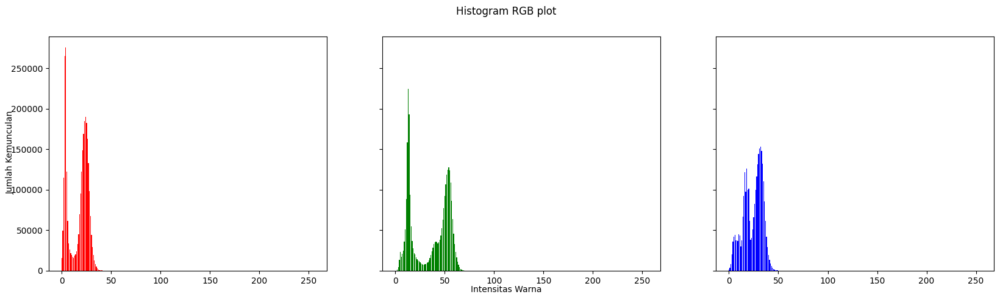

In [ ]:
# Pertanyaan praktikum 1 untuk ktm1a
img = cv.imread(BASE + 'ktm1a.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(0, height):
  for x in range(0, width):
    red[img[y, x, 0]] += 1
    green[img[y, x, 1]] += 1
    blue[img[y, x, 2]] += 1

names = np.arange(256)
manual_red = np.array(red)
manual_green = np.array(green)
manual_blue = np.array(blue)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex= True, sharey= True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va = 'center', rotation = 'vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha = 'center')
axs[0].bar(names, red, color = 'red')
axs[1].bar(names, green, color = 'green')
axs[2].bar(names, blue, color = 'blue')

# Histogram citra dengan numpy.histogram ktm1a
np_red, _ = np.histogram(img[:, :, 0], bins=256, range=(0, 256))
np_green, _ = np.histogram(img[:, :, 1], bins=256, range=(0, 256))
np_blue, _ = np.histogram(img[:, :, 2], bins=256, range=(0, 256))

# Histogram citra dengan cv.calchist
cv_red = cv.calcHist([img], [0], None, [256], [0, 256]).flatten().astype(int)
cv_green = cv.calcHist([img], [1], None, [256], [0, 256]).flatten().astype(int)
cv_blue = cv.calcHist([img], [2], None, [256], [0, 256]).flatten().astype(int)

# Perbandingan selisih maksimum
print("=== Perbandingan histogram: ktm1a.jpg ===")

diff_r_manual_np = np.max(np.abs(manual_red - np_red))
diff_r_manual_cv = np.max(np.abs(manual_red - cv_red))
diff_r_np_cv = np.max(np.abs(np_red - cv_red))
print(f"Kanal red   | manual vs numpy: {diff_r_manual_np} | manual vs cv: {diff_r_manual_cv} | numpy vs cv: {diff_r_np_cv}")

diff_g_manual_np = np.max(np.abs(manual_green - np_green))
diff_g_manual_cv = np.max(np.abs(manual_green - cv_green))
diff_g_np_cv = np.max(np.abs(np_green - cv_green))
print(f"Kanal green | manual vs numpy: {diff_g_manual_np} | manual vs cv: {diff_g_manual_cv} | numpy vs cv: {diff_g_np_cv}")

diff_b_manual_np = np.max(np.abs(manual_blue - np_blue))
diff_b_manual_cv = np.max(np.abs(manual_blue - cv_blue))
diff_b_np_cv = np.max(np.abs(np_blue - cv_blue))
print(f"Kanal blue  | manual vs numpy: {diff_b_manual_np} | manual vs cv: {diff_b_manual_cv} | numpy vs cv: {diff_b_np_cv}")

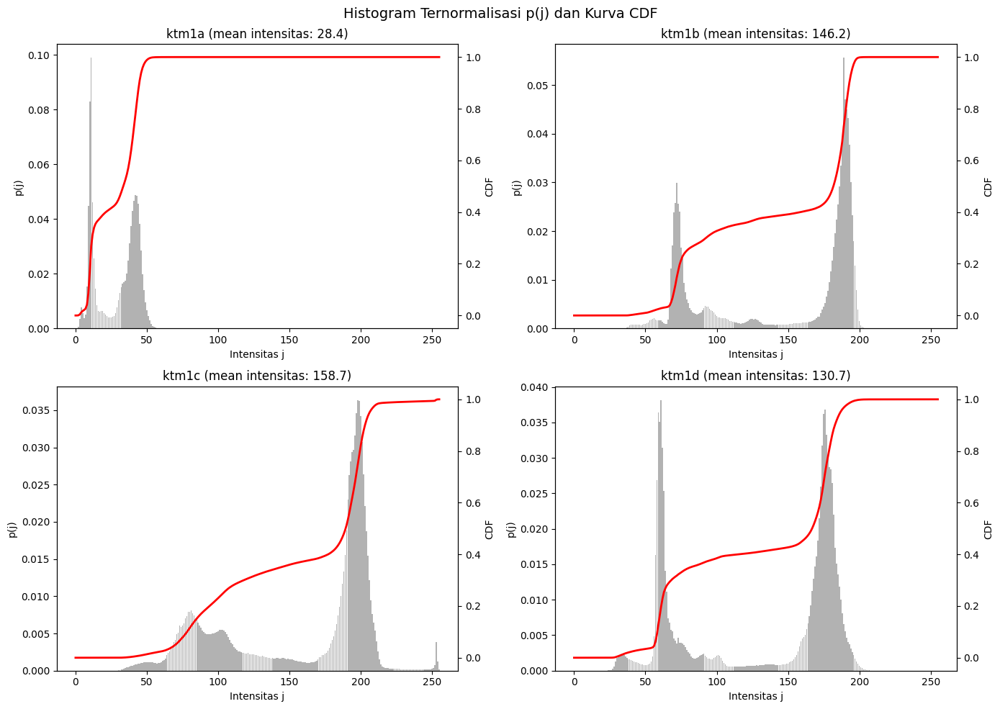

In [ ]:
# E-1 Pertanyaan Praktikum 2
paths = {
    'ktm1a': BASE + 'ktm1a.jpg',
    'ktm1b': BASE + 'ktm1b.jpg',
    'ktm1c': BASE + 'ktm1c.jpg',
    'ktm1d': BASE + 'ktm1d.jpg',
}

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.ravel()

for ax, (label, path) in zip(axs, paths.items()):
    img = cv.imread(path)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    hist, _ = np.histogram(gray, bins=256, range=(0, 256))
    p = hist / hist.sum()          # histogram ternormalisasi p(j)
    cdf = np.cumsum(p)             # kurva CDF

    ax.bar(np.arange(256), p, color='gray', alpha=0.6, label='p(j)')
    ax_cdf = ax.twinx()
    ax_cdf.plot(np.arange(256), cdf, color='red', linewidth=2, label='CDF')

    ax.set_title(f'{label} (mean intensitas: {gray.mean():.1f})')
    ax.set_xlabel('Intensitas j')
    ax.set_ylabel('p(j)')
    ax_cdf.set_ylabel('CDF')

fig.suptitle('Histogram Ternormalisasi p(j) dan Kurva CDF', fontsize=14)
plt.tight_layout()
plt.show()

## Kaitan dengan kondisi pencahayaan
Pada ktm 1a kruva cdf melonjak tajam di intensitas rendah (<50) lalu datar setelahnya. hal ini menunjukkan citra diambil di kondisi cahay gelap atau minim cahata sehingga hampir seluruh piksel bernilai gelap dan grafik histogram nya berkumpul di piksel gelap

Sementara pada ktm 1c yang menggunakan cahaya terang + flash cdf awalnya landai lalu naik tajam di intensitas tinggi (150 - 200) menunjukkan bahwa citra diambil dengan pencahayaan cukup atau berlebih sehingga sebagian besar piksel bernilai terang


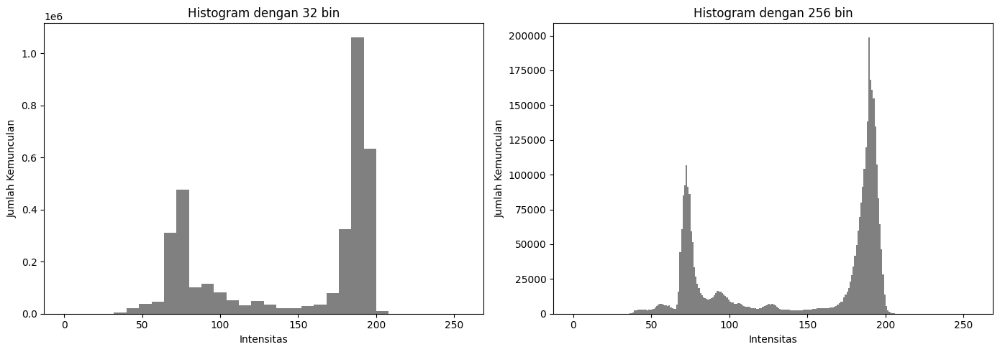

In [ ]:
# E-1 Pertanyaan Praktikum 3
img = cv.imread(BASE + 'ktm1b.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Histogram dengan parameter bins
axs[0].hist(gray.ravel(), bins=PARAM['bins'], range=(0, 256), color='gray')
axs[0].set_title(f"Histogram dengan {PARAM['bins']} bin")
axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Jumlah Kemunculan')

# Histogram dengan 256 bin
axs[1].hist(gray.ravel(), bins=256, range=(0, 256), color='gray')
axs[1].set_title('Histogram dengan 256 bin')
axs[1].set_xlabel('Intensitas')
axs[1].set_ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

# Informasi yang hilang

1. di sekitar intensitas 190 - 200 pada bin 256 memiliki detail halus yang menunjukkan intensitas tiap piksel sementara pada histogram dengan 32 bin 190 - 200 menjadi satu blok puncak yang sama
2. Pada histogram 256 bin di intensitas sekitar 70 ada puncak kecil yang terpisah dari sekitarnya, sementara di 32 bin puncak itu melebar dan menjadi tumpul karena piksel di sekitar nilai 70 digabungkan menjadi satu bin
3. Informasi di sumbu x yang tidak bisa dibedakan akibat pengurangan bin. Pada bin 256 kita bisa membandingkan berapa frekuensi yang dimiliki oleh intensitas 198, 199, dan 200 sementara pada bin 32 kita tidak bisa membedangan hal tersebut karena semuanya terletak pada bin yang sama sehingga dianggap sama
4. Nilai puncak jadi tidak presisi, pada bin 256 kita bisa melihat puncak di intensitas berapa sementara di bin 32 kita hanya bisa melihat puncak tersebut ada di range berapa

# E-2

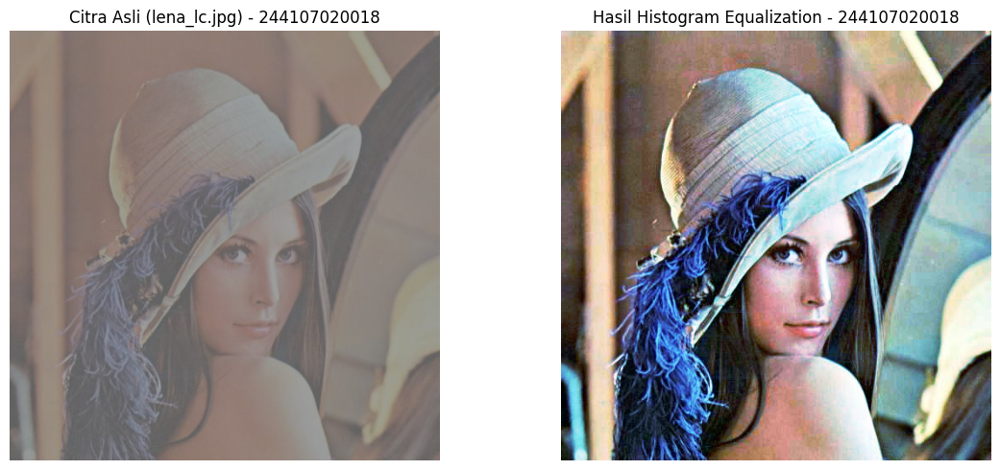

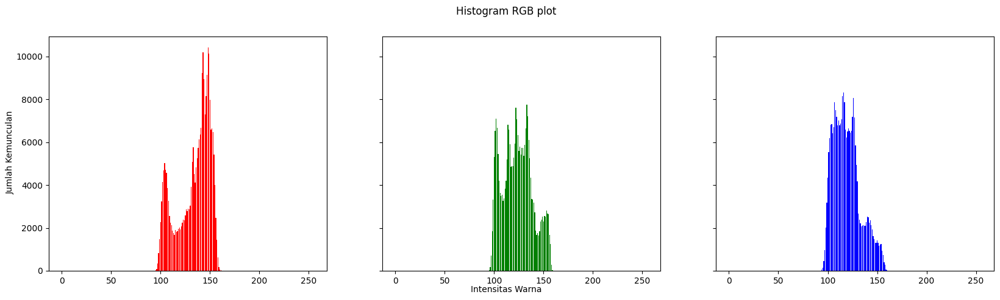

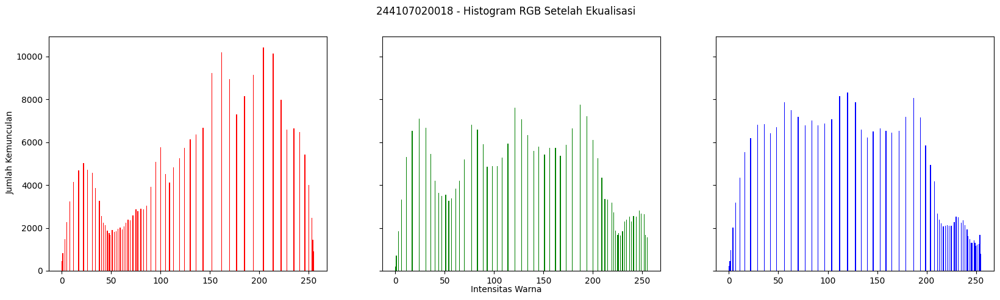

In [ ]:
# E2 Percobaan 1
img_lena = cv.imread(CONTOH + 'lena_lc.jpg')
img_lena = cv.cvtColor(img_lena, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img_lena)
names = np.arange(256)

red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(0, height):
  for x in range(0, width):
    red[img_lena[y, x, 0]] += 1
    green[img_lena[y, x, 1]] += 1
    blue[img_lena[y, x, 2]] += 1

total_pixels = height * width

# Variabel untuk menampung nilai cdf
red_cdf = 0
green_cdf = 0
blue_cdf = 0

# Array untuk menyimpan peta perubahan warna (pemetaan nilai pixel lama ke baru)
map_red = [0] * 256
map_green = [0] * 256
map_blue = [0] * 256

for i in range(256):
  red_cdf += red[i]
  green_cdf += green[i]
  blue_cdf += blue[i]

  map_red[i] = round((red_cdf / total_pixels) * 255)
  map_green[i] = round((green_cdf / total_pixels) * 255)
  map_blue[i] = round((blue_cdf / total_pixels) * 255)

img_eq_lena = np.zeros_like(img_lena)

for y in range(0, height):
    for x in range(0, width):
        # Mengganti pixel lama dengan pixel baru berdasarkan pemetaan
        img_eq_lena[y, x, 0] = map_red[img_lena[y, x, 0]]
        img_eq_lena[y, x, 1] = map_green[img_lena[y, x, 1]]
        img_eq_lena[y, x, 2] = map_blue[img_lena[y, x, 2]]


fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(img_lena)
axs[0].set_title('Citra Asli (lena_lc.jpg) - ' + NIM )
axs[0].axis('off')

axs[1].imshow(img_eq_lena)
axs[1].set_title('Hasil Histogram Equalization - ' + NIM )
axs[1].axis('off')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex= True, sharey= True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va = 'center', rotation = 'vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha = 'center')
axs[0].bar(names, red, color = 'red')
axs[1].bar(names, green, color = 'green')
axs[2].bar(names, blue, color = 'blue')

# Hitung histogram dari CITRA HASIL EKUALISASI (img_eq_lena), bukan dari map_red
red_eq = [0] * 256
green_eq = [0] * 256
blue_eq = [0] * 256

for y in range(0, height):
  for x in range(0, width):
    red_eq[img_eq_lena[y, x, 0]] += 1
    green_eq[img_eq_lena[y, x, 1]] += 1
    blue_eq[img_eq_lena[y, x, 2]] += 1

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB Setelah Ekualisasi')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red_eq, color='red')
axs[1].bar(names, green_eq, color='green')
axs[2].bar(names, blue_eq, color='blue')
plt.show()


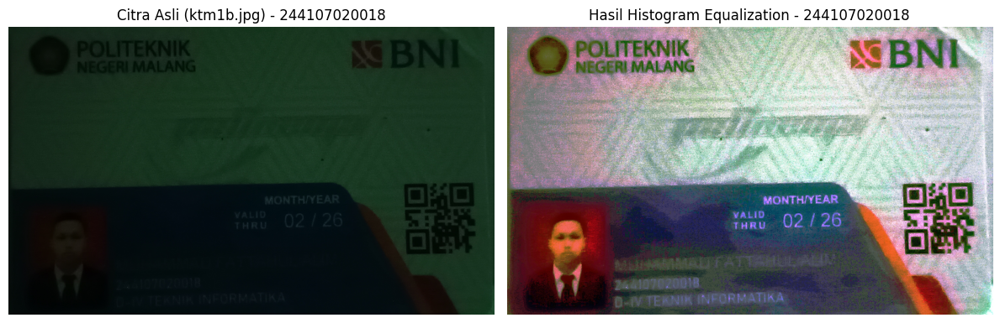

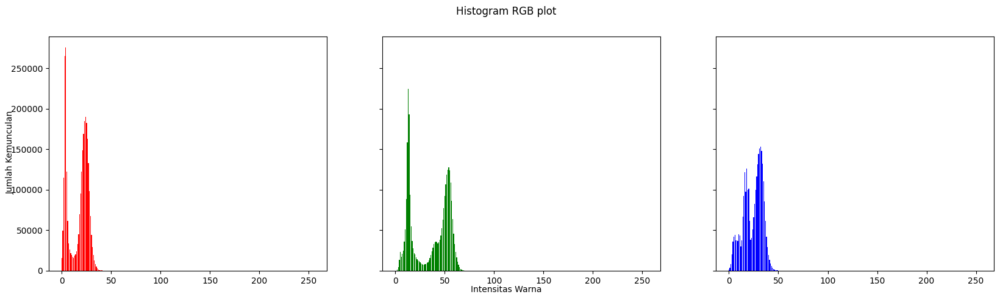

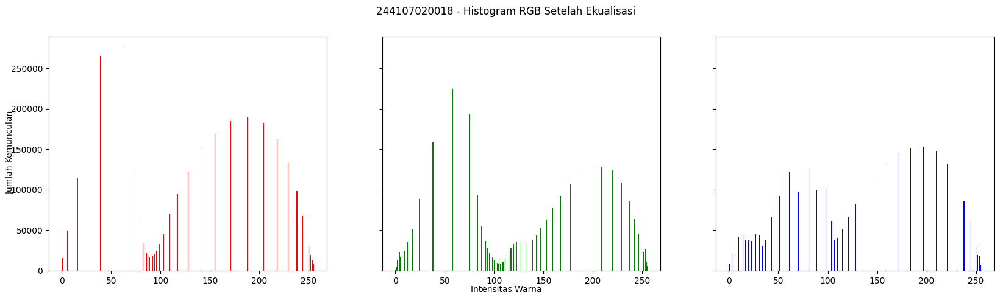

In [ ]:
#E2 Percobaan 1 bagian ktm
img_ktm = cv.imread(BASE + 'ktm1a.jpg')
img_ktm = cv.cvtColor(img_ktm, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img_ktm)
names = np.arange(256)

red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(0, height):
  for x in range(0, width):
    red[img_ktm[y, x, 0]] += 1
    green[img_ktm[y, x, 1]] += 1
    blue[img_ktm[y, x, 2]] += 1

total_pixels = height * width

# Variabel untuk menampung nilai cdf
red_cdf = 0
green_cdf = 0
blue_cdf = 0

# Array untuk menyimpan peta perubahan warna (pemetaan nilai pixel lama ke baru)
map_red = [0] * 256
map_green = [0] * 256
map_blue = [0] * 256

for i in range(256):
  red_cdf += red[i]
  green_cdf += green[i]
  blue_cdf += blue[i]

  map_red[i] = round((red_cdf / total_pixels) * 255)
  map_green[i] = round((green_cdf / total_pixels) * 255)
  map_blue[i] = round((blue_cdf / total_pixels) * 255)

img_eq_ktm = np.zeros_like(img_ktm)

for y in range(0, height):
    for x in range(0, width):
        # Mengganti pixel lama dengan pixel baru berdasarkan pemetaan
        img_eq_ktm[y, x, 0] = map_red[img_ktm[y, x, 0]]
        img_eq_ktm[y, x, 1] = map_green[img_ktm[y, x, 1]]
        img_eq_ktm[y, x, 2] = map_blue[img_ktm[y, x, 2]]


fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(img_ktm)
axs[0].set_title('Citra Asli (ktm1b.jpg) - ' + NIM)
axs[0].axis('off')

axs[1].imshow(img_eq_ktm)
axs[1].set_title('Hasil Histogram Equalization - ' + NIM)
axs[1].axis('off')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex= True, sharey= True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va = 'center', rotation = 'vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha = 'center')
axs[0].bar(names, red, color = 'red')
axs[1].bar(names, green, color = 'green')
axs[2].bar(names, blue, color = 'blue')


red_eq = [0] * 256
green_eq = [0] * 256
blue_eq = [0] * 256

for y in range(0, height):
  for x in range(0, width):
    red_eq[img_eq_ktm[y, x, 0]] += 1
    green_eq[img_eq_ktm[y, x, 1]] += 1
    blue_eq[img_eq_ktm[y, x, 2]] += 1

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB Setelah Ekualisasi')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red_eq, color='red')
axs[1].bar(names, green_eq, color='green')
axs[2].bar(names, blue_eq, color='blue')
plt.show()


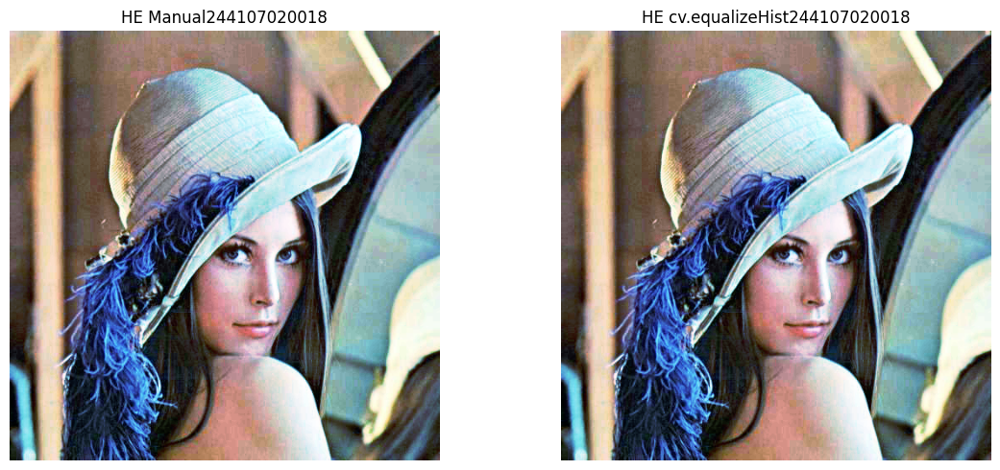

Selisih maksimum (lena_lc.jpg) manual vs cv.equalizeHist: 0


In [ ]:
# E-2 Percobaan 2
r, g, b = cv.split(img_lena)

r_equalized = cv.equalizeHist(r)
g_equalized = cv.equalizeHist(g)
b_equalized = cv.equalizeHist(b)

img_eq_cv = cv.merge([r_equalized, g_equalized, b_equalized])

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(img_eq_lena)
axs[0].set_title('HE Manual' + NIM)
axs[0].axis('off')

axs[1].imshow(img_eq_cv)
axs[1].set_title('HE cv.equalizeHist' + NIM)
axs[1].axis('off')
plt.tight_layout()
plt.show()

diff_lena = np.max(np.abs(img_eq_lena.astype(int) - img_eq_cv.astype(int)))
print("Selisih maksimum (lena_lc.jpg) manual vs cv.equalizeHist:", diff_lena)

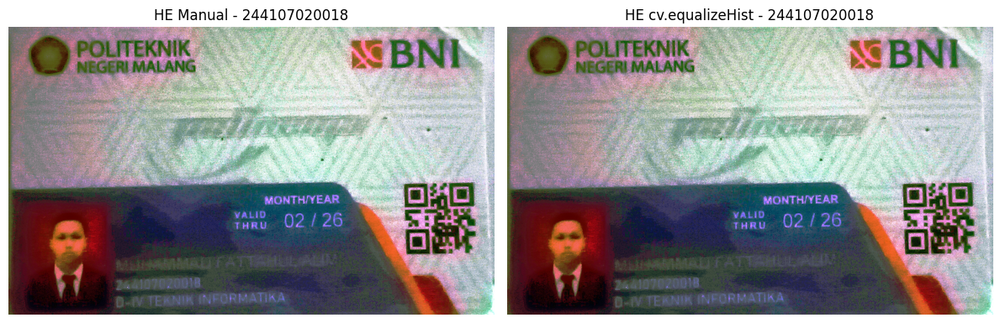

Selisih maksimum (KTM1a.jpg) manual vs cv.equalizeHist: 2


In [ ]:
# E-2 Percobaan 2 bagian ktm
r, g, b = cv.split(img_ktm)

r_equalized = cv.equalizeHist(r)
g_equalized = cv.equalizeHist(g)
b_equalized = cv.equalizeHist(b)

img_eq_cv = cv.merge([r_equalized, g_equalized, b_equalized])

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(img_eq_ktm)
axs[0].set_title( 'HE Manual - ' + NIM)
axs[0].axis('off')

axs[1].imshow(img_eq_cv)
axs[1].set_title( 'HE cv.equalizeHist - ' + NIM)
axs[1].axis('off')
plt.tight_layout()
plt.show()

diff_ktm = np.max(np.abs(img_eq_ktm.astype(int) - img_eq_cv.astype(int)))
print("Selisih maksimum (KTM1a.jpg) manual vs cv.equalizeHist:", diff_ktm)

Terdapat selisih 2 pada foto ktm yang kemungkinan terjadi akibat perbedaan rumus normalisasi CDF antara implementasi manual (tidak mengurangi CDF_min) dengan cv.equalizeHist(mengurangi CDF_min agar histogram meregang penuh ke rentang 0-255)

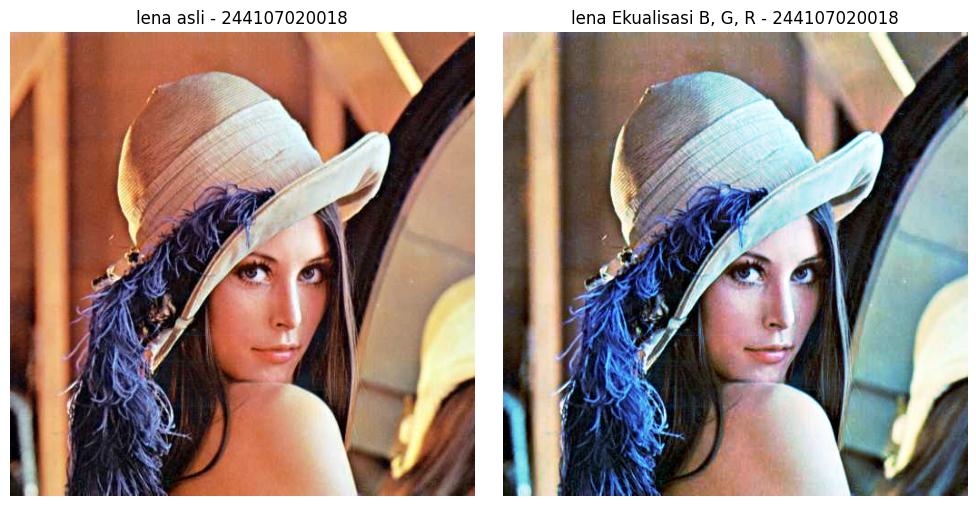

In [ ]:
# E-2 Percobaan 3
berkas = CONTOH + 'lena.jpg'
bgr = cv.imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
axs[0].set_title('lena asli - ' + NIM)
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
axs[1].set_title('lena Ekualisasi B, G, R - ' + NIM)
axs[1].axis('off')

plt.tight_layout()
plt.show()

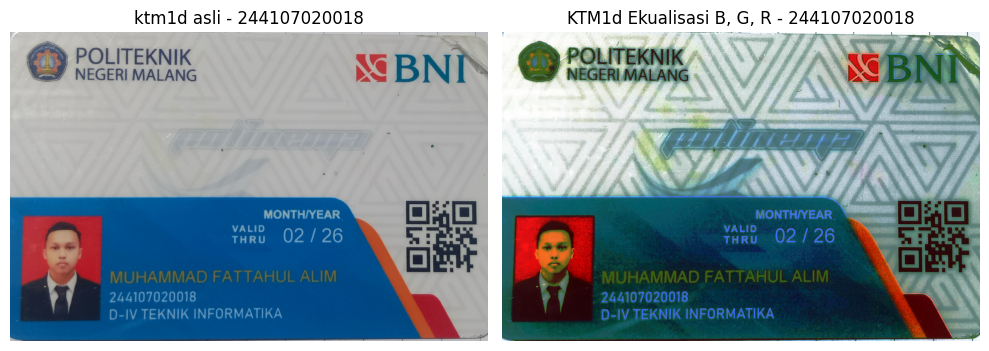

In [ ]:
# E-2 Percobaan 3 bagian ktm
berkas2 = BASE + 'ktm1d.jpg'
bgr2 = cv.imread(berkas2)

kanal2 = list(cv.split(bgr2))
for i in range(3):
    kanal2[i] = cv.equalizeHist(kanal2[i])
he_rgb2 = cv.merge(kanal2)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cv.cvtColor(bgr2, cv.COLOR_BGR2RGB))
axs[0].set_title('ktm1d asli - ' + NIM)
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(he_rgb2, cv.COLOR_BGR2RGB))
axs[1].set_title('KTM1d Ekualisasi B, G, R - ' + NIM)
axs[1].axis('off')

plt.tight_layout()
plt.show()

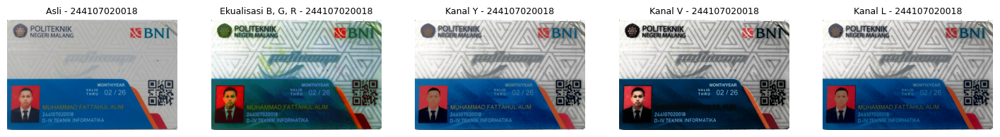

In [ ]:
# E-2 Perobaan 4
ycrcb = cv.cvtColor(bgr2, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# varian setara pada ruang warna lain
hsv = cv.cvtColor(bgr2, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr2, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr2, he_rgb2, he_y, he_v, he_l]   # he_rgb2 dari soal nomor 3

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(t + ' - ' + NIM, fontsize=9)
    plt.axis('off')
plt.show()

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            130.7
Ekualisasi B, G, R                69.12            123.8
Kanal Y                            1.29            131.2
Kanal V                            2.33            115.2
Kanal L                            7.56            122.5
Pergeseran Hue CLAHE: 0.2138194008423016
Rerata kecerahan CLAHE: 133.1893576807699
(clipLimit=2.5, tileGridSize=(4,4))


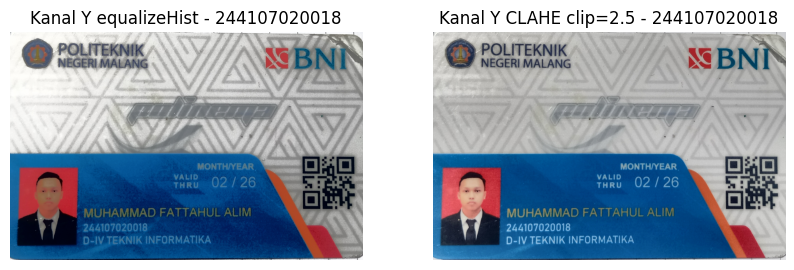

In [ ]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)  # Hue melingkar 0-179
    return d.mean()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr2, c) * 2,
                                    cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))

y_clahe = clahe.apply(y)
he_clahe = cv.cvtColor(cv.merge([y_clahe, cr, cb]), cv.COLOR_YCrCb2BGR)

print("Pergeseran Hue CLAHE:", geser_hue(bgr2, he_clahe) * 2)
print("Rerata kecerahan CLAHE:", cv.cvtColor(he_clahe, cv.COLOR_BGR2GRAY).mean())
print(f"(clipLimit={PARAM['clip']}, tileGridSize=({PARAM['tile']},{PARAM['tile']}))")

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cv.cvtColor(he_y, cv.COLOR_BGR2RGB))
axs[0].set_title('Kanal Y equalizeHist - ' + NIM)
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(he_clahe, cv.COLOR_BGR2RGB))
axs[1].set_title(f'Kanal Y CLAHE clip={PARAM["clip"]} - ' + NIM)
axs[1].axis('off')
plt.show()

# Tabel hasil
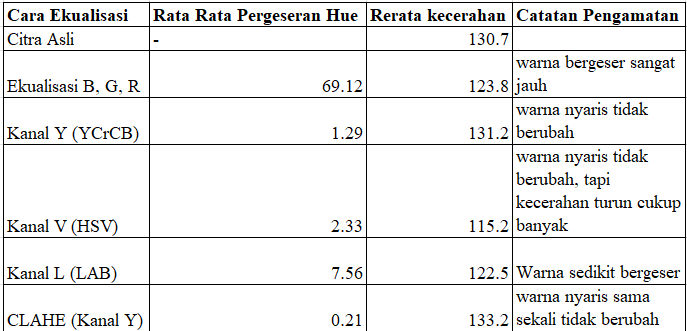




## Jawaban pertanyaan
1. Ekualisasi kanal B, G, R secara terpisah, dengan pergeseran Hue 69.12°. Pergesaran yang besar ini terjadi akibat tiap kanal warna harus diregangkan satu persatu tanpa mempertimbangkan hubungan proporsional antar kanal sehingga rasio B:G:R di tiap piksel berubah drastis dan rasio itu yang menentukan hue
2. Ekualisasi kanal terang tetap menghasilkan pergeseran Hue karena adanya batasan rentang nilai pada format citra digital 8-bit saat dikonversi kembali ke ruang warna BGR. Proses konversi ini memicu dua masalah matematis: pembulatan nilai desimal menjadi bilangan bulat (rounding) dan pemotongan paksa (clipping) pada nilai piksel hasil peregangan kontras yang melampaui batas 0-255. Kedua proses tersebut secara langsung merusak proporsi atau rasio asli antara ketiga kanal warna (Biru, Hijau, Merah), sehingga komposisi warnanya berubah dan nilai Hue bergeser dari aslinya.
3. Kanal Y yang paling sesuai karena pergeseran hue yang kecil dengan rerata kecerahan yang paling mendekati dengan citra asli. dari semua kanal tersebut bagian nama dan nim di kanal Y juga yang paling jelas berdasarkan visual
4. CLAHE menghasilkan pergeseran Hue yang jauh lebih kecil dibanding equalizeHist. Ini karena CLAHE bekerja secara lokal per-tile dengan tileGridSize=(4,4) dan clipLimit=2.5, sehingga perubahan kontras per piksel jauh lebih halus dan terkontrol dibanding equalizeHist yang meregangkan seluruh histogram citra sekaligus secara global. Menunjukkan CLAHE memperbaiki kontras tanpa mengubah karakter warna dan kecerahan citra secara drastis.

# Pertanyaan Praktikum 2

In [ ]:
# 1.
img_a = cv.imread(BASE + 'ktm1a.jpg')
gray_a = cv.cvtColor(img_a, cv.COLOR_BGR2GRAY)

height_a, width_a = np.shape(gray_a)

# Histogram manual
hist_a = [0] * 256
for y in range(0, height_a):
  for x in range(0, width_a):
    hist_a[gray_a[y, x]] += 1

total_pixels_a = height_a * width_a

cdf_a = 0
map_a = [0] * 256
for i in range(256):
  cdf_a += hist_a[i]
  map_a[i] = round((cdf_a / total_pixels_a) * 255)

hasil_manual_a = np.zeros_like(gray_a)
for y in range(0, height_a):
  for x in range(0, width_a):
    hasil_manual_a[y, x] = map_a[gray_a[y, x]]

hasil_cv_a = cv.equalizeHist(gray_a)

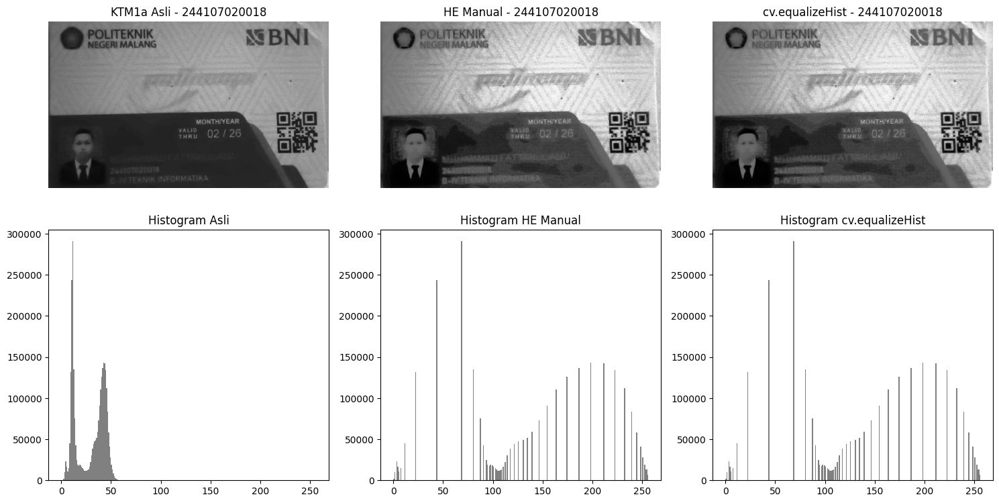

In [ ]:
# Menampilkan citra asli, hasil manual, hasil cv.equalizeHist dan histogram masing-masing
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

axs[0,0].imshow(gray_a, cmap='gray')
axs[0,0].set_title('KTM1a Asli - ' + NIM)
axs[0,0].axis('off')

axs[0,1].imshow(hasil_manual_a, cmap='gray')
axs[0,1].set_title('HE Manual - ' + NIM)
axs[0,1].axis('off')

axs[0,2].imshow(hasil_cv_a, cmap='gray')
axs[0,2].set_title('cv.equalizeHist - ' + NIM)
axs[0,2].axis('off')

axs[1,0].hist(gray_a.ravel(), bins=256, range=(0,256), color='gray')
axs[1,0].set_title('Histogram Asli')

axs[1,1].hist(hasil_manual_a.ravel(), bins=256, range=(0,256), color='gray')
axs[1,1].set_title('Histogram HE Manual')

axs[1,2].hist(hasil_cv_a.ravel(), bins=256, range=(0,256), color='gray')
axs[1,2].set_title('Histogram cv.equalizeHist')

plt.tight_layout()
plt.show()

In [ ]:
# PSNR asli vs HE manual
mse_manual = np.mean((gray_a.astype(np.float64) - hasil_manual_a.astype(np.float64)) ** 2)
psnr_manual = 10 * np.log10((255 ** 2) / mse_manual)

# PSNR asli vs HE cv.equalizeHist
mse_cv = np.mean((gray_a.astype(np.float64) - hasil_cv_a.astype(np.float64)) ** 2)
psnr_cv = 10 * np.log10((255 ** 2) / mse_cv)

print(f"PSNR asli vs HE manual: {psnr_manual:.2f} dB")
print(f"PSNR asli vs HE cv.equalizeHist: {psnr_cv:.2f} dB")

PSNR asli vs HE manual: 6.60 dB
PSNR asli vs HE cv.equalizeHist: 6.60 dB


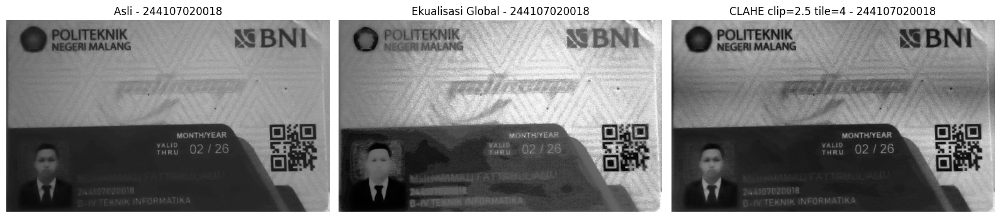

In [ ]:
# 2.
# CLAHE pada KTM1a.jpg grayscale
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
hasil_clahe_a = clahe.apply(gray_a)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))

axs[0].imshow(gray_a, cmap='gray')
axs[0].set_title('Asli - ' + NIM)
axs[0].axis('off')

axs[1].imshow(hasil_cv_a, cmap='gray')
axs[1].set_title('Ekualisasi Global - ' + NIM)
axs[1].axis('off')

axs[2].imshow(hasil_clahe_a, cmap='gray')
axs[2].set_title(f'CLAHE clip={PARAM["clip"]} tile={PARAM["tile"]} - ' + NIM)
axs[2].axis('off')

plt.tight_layout()
plt.show()

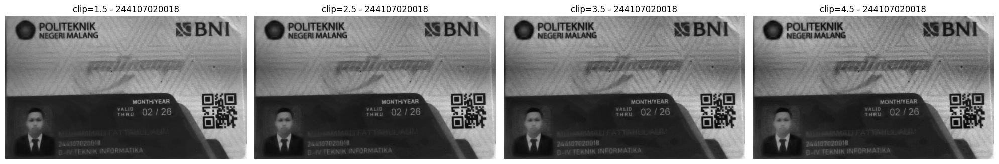

In [ ]:
# Nilai clipLimit lain di sekitar PARAM['clip']
clip_a = PARAM['clip'] - 1.0
clip_b = PARAM['clip']            # nilai asli dari NIM
clip_c = PARAM['clip'] + 1.0
clip_d = PARAM['clip'] + 2.0

clahe_a = cv.createCLAHE(clipLimit=max(clip_a, 0.5), tileGridSize=(PARAM['tile'], PARAM['tile']))
clahe_c = cv.createCLAHE(clipLimit=clip_c, tileGridSize=(PARAM['tile'], PARAM['tile']))
clahe_d = cv.createCLAHE(clipLimit=clip_d, tileGridSize=(PARAM['tile'], PARAM['tile']))

hasil_a = clahe_a.apply(gray_a)
hasil_b = hasil_clahe_a   # dari sel sebelumnya, pakai clip asli
hasil_c = clahe_c.apply(gray_a)
hasil_d = clahe_d.apply(gray_a)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
judul_clip = [max(clip_a, 0.5), clip_b, clip_c, clip_d]
hasil_clip = [hasil_a, hasil_b, hasil_c, hasil_d]

for i in range(4):
    axs[i].imshow(hasil_clip[i], cmap='gray')
    axs[i].set_title(f'clip={judul_clip[i]} - ' + NIM)
    axs[i].axis('off')

plt.tight_layout()
plt.show()

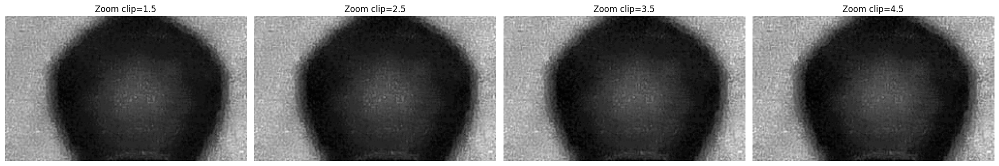

In [ ]:
# Ganti koordinat ini sesuai lokasi area polos/gelap di citra KTM-mu
y1, y2, x1, x2 = 50, 200, 50, 300  # sesuaikan dengan posisi background/area gelap

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
for i in range(4):
    crop = hasil_clip[i][y1:y2, x1:x2]
    axs[i].imshow(crop, cmap='gray')
    axs[i].set_title(f'Zoom clip={judul_clip[i]}')
    axs[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
print('%-12s %16s' % ('clipLimit', 'Std area crop'))
for i in range(4):
    crop = hasil_clip[i][y1:y2, x1:x2]
    std_crop = np.std(crop)
    print('%-12s %16.2f' % (judul_clip[i], std_crop))

clipLimit       Std area crop
1.5                     20.60
2.5                     28.24
3.5                     33.88
4.5                     37.87


# 3

In [ ]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step     # warna palet terdekat
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                 img[y,   x+1] += error * 7 / 16
            if x > 0 and y+1 < H:         img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:                 img[y+1, x  ] += error * 5 / 16
            if x + 1 < W and y+1 < H:     img[y+1, x+1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

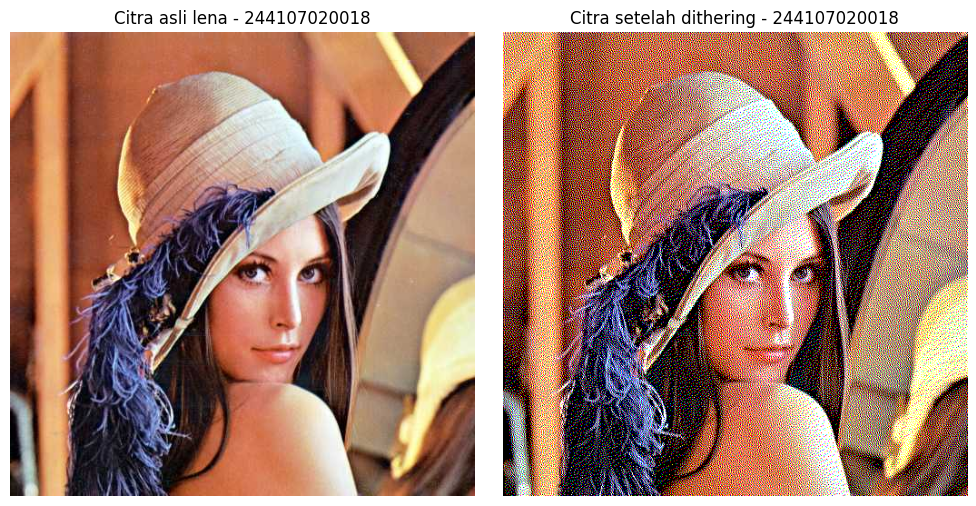

In [ ]:
img_lena = cv.imread(CONTOH + 'lena.jpg')

b, g, r = cv.split(img_lena)
b_dither_lena = floyd_steinberg(b, L=2)
g_dither_lena = floyd_steinberg(g, L=2)
r_dither_lena = floyd_steinberg(r, L=2)
hasil_dither_lena = cv.merge([b_dither_lena, g_dither_lena, r_dither_lena])

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cv.cvtColor(img_lena, cv.COLOR_BGR2RGB))
axs[0].set_title('Citra asli lena - ' + NIM)
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(hasil_dither_lena, cv.COLOR_BGR2RGB))
axs[1].set_title('Citra setelah dithering - ' + NIM)
axs[1].axis('off')

plt.tight_layout()
plt.show()

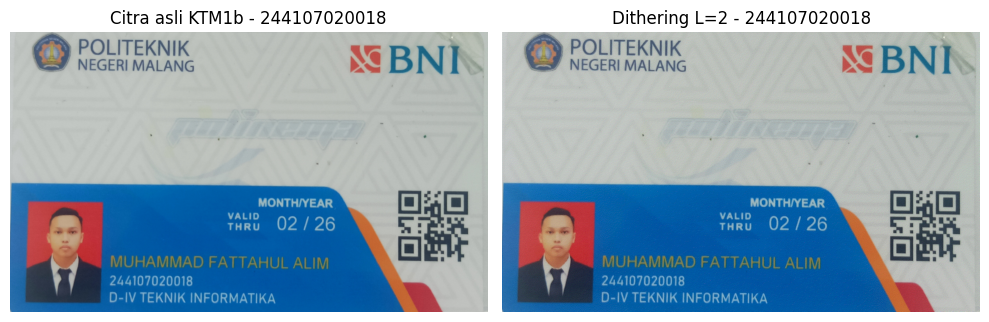

Rata-rata selisih piksel: 95.48244483902415
Selisih maksimum piksel: 254


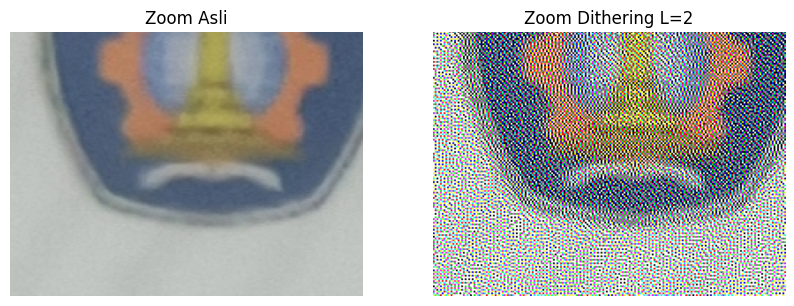

In [ ]:
img_ktmb = cv.imread(BASE + 'ktm1b.jpg')

b, g, r = cv.split(img_ktmb)
b_dither = floyd_steinberg(b, L=PARAM['L'])
g_dither = floyd_steinberg(g, L=PARAM['L'])
r_dither = floyd_steinberg(r, L=PARAM['L'])
hasil_dither_ktmb = cv.merge([b_dither, g_dither, r_dither])

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cv.cvtColor(img_ktmb, cv.COLOR_BGR2RGB))
axs[0].set_title('Citra asli KTM1b - ' + NIM)
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(hasil_dither_ktmb, cv.COLOR_BGR2RGB))
axs[1].set_title(f'Dithering L={PARAM["L"]} - ' + NIM)
axs[1].axis('off')

plt.tight_layout()
plt.show()

diff_ktmb = np.abs(img_ktmb.astype(int) - hasil_dither_ktmb.astype(int))
print("Rata-rata selisih piksel:", diff_ktmb.mean())
print("Selisih maksimum piksel:", diff_ktmb.max())

y1, y2, x1, x2 = 100, 250, 100, 300  # sesuaikan koordinat area citra kamu

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cv.cvtColor(img_ktmb[y1:y2, x1:x2], cv.COLOR_BGR2RGB))
axs[0].set_title('Zoom Asli')
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(hasil_dither_ktmb[y1:y2, x1:x2], cv.COLOR_BGR2RGB))
axs[1].set_title(f'Zoom Dithering L={PARAM["L"]}')
axs[1].axis('off')
plt.show()

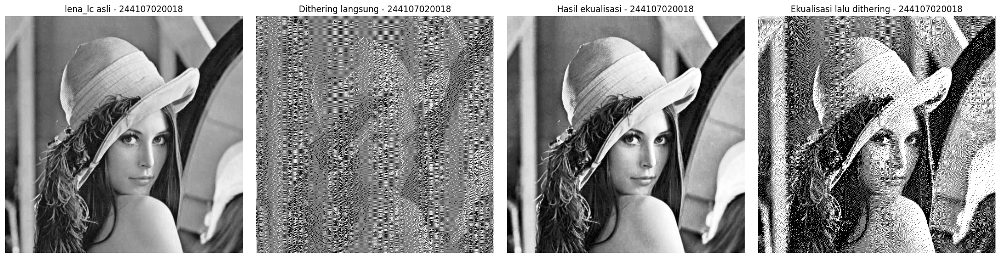

In [ ]:
img_lc = cv.imread(CONTOH + '/lena_lc.jpg')
gray_lc = cv.cvtColor(img_lc, cv.COLOR_BGR2GRAY)

# 1. Dithering langsung tanpa ekualisasi
dither_langsung_lc = floyd_steinberg(gray_lc, L=2)

# 2. Histogram equalization dulu, baru dithering
hasil_eq_lc = cv.equalizeHist(gray_lc)
dither_eq_lc = floyd_steinberg(hasil_eq_lc, L=2)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

axs[0].imshow(gray_lc, cmap='gray')
axs[0].set_title('lena_lc asli - ' + NIM)
axs[0].axis('off')

axs[1].imshow(dither_langsung_lc, cmap='gray')
axs[1].set_title('Dithering langsung - ' + NIM)
axs[1].axis('off')

axs[2].imshow(hasil_eq_lc, cmap='gray')
axs[2].set_title('Hasil ekualisasi - ' + NIM)
axs[2].axis('off')

axs[3].imshow(dither_eq_lc, cmap='gray')
axs[3].set_title('Ekualisasi lalu dithering - ' + NIM)
axs[3].axis('off')

plt.tight_layout()
plt.show()

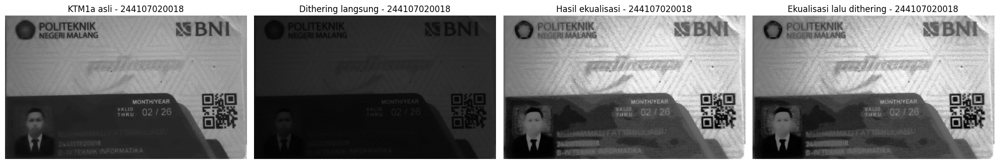

Nilai unik di 'Hasil ekualisasi': [ 0  1  3  4  5  7 11 22 43 68] ... total: 52
Nilai unik di 'Ekualisasi lalu dithering': [  0 255]


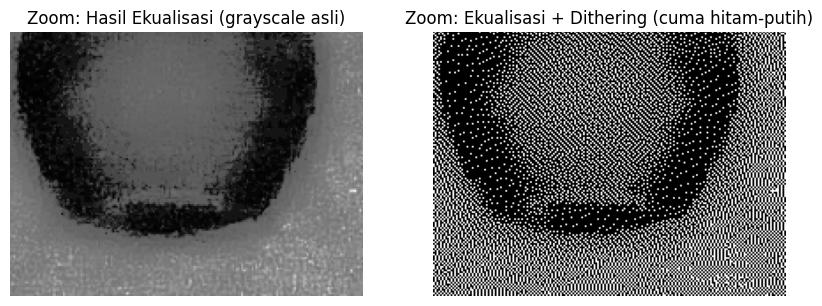

In [ ]:
img_a = cv.imread(BASE + 'ktm1a.jpg')
gray_a_dith = cv.cvtColor(img_a, cv.COLOR_BGR2GRAY)

# 1. Dithering langsung tanpa ekualisasi
dither_langsung_a = floyd_steinberg(gray_a_dith, L=2)

# 2. Histogram equalization dulu, baru dithering
hasil_eq_a = cv.equalizeHist(gray_a_dith)
dither_eq_a = floyd_steinberg(hasil_eq_a, L=2)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

axs[0].imshow(gray_a_dith, cmap='gray')
axs[0].set_title('KTM1a asli - ' + NIM)
axs[0].axis('off')

axs[1].imshow(dither_langsung_a, cmap='gray')
axs[1].set_title('Dithering langsung - ' + NIM)
axs[1].axis('off')

axs[2].imshow(hasil_eq_a, cmap='gray')
axs[2].set_title('Hasil ekualisasi - ' + NIM)
axs[2].axis('off')

axs[3].imshow(dither_eq_a, cmap='gray')
axs[3].set_title('Ekualisasi lalu dithering - ' + NIM)
axs[3].axis('off')

plt.tight_layout()
plt.show()

print("Nilai unik di 'Hasil ekualisasi':", np.unique(hasil_eq_a)[:10], "... total:", len(np.unique(hasil_eq_a)))
print("Nilai unik di 'Ekualisasi lalu dithering':", np.unique(dither_eq_a))

y1, y2, x1, x2 = 100, 250, 100, 300  # sesuaikan dengan area wajah/teks di citramu

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(hasil_eq_a[y1:y2, x1:x2], cmap='gray')
axs[0].set_title('Zoom: Hasil Ekualisasi (grayscale asli)')
axs[0].axis('off')

axs[1].imshow(dither_eq_a[y1:y2, x1:x2], cmap='gray')
axs[1].set_title('Zoom: Ekualisasi + Dithering (cuma hitam-putih)')
axs[1].axis('off')
plt.show()

Melakukan ekualisasi lalu baru dilakukan dithering menghasilkan hasil yang lebih baik daripada dithering langsung, NIM dan teks nama pada ekualisasi + dithering lebih jelas secara visual. Hal ini terjadi akibat dithering langsung yang kurang cocok untuk citra dengan kondisi pencahayaan buruk karena dithering tanpa ekualisasi cenderung menghasilkan citra yang terlalu gelap sehingga kehilangan detail penting

In [8]:
!jupyter nbconvert --to html "/content/drive/MyDrive/PCVK-MFattahul/week-5/Week5_15.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/PCVK-MFattahul/week-5/Week5_15.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 27 image(s).
[NbConvertApp] Writing 14623451 bytes to /content/drive/MyDrive/PCVK-MFattahul/week-5/Week5_15.html
